
# Supresvised Learning. Classification

Topics: pytorch, data preparation, data augmentation, custom model, transfer learning, classification, segmentation

Main Tasks
1. Solve the road photo **classification** problem
  1. Prepare data and solve imbalanced dataset problem
  2. Implement and train a custom classifier
  3. Implement validation pipeline
  4. Add data augmentation and compare results
  5. Load pre-trained model and tune for road photos (transfer learning)


 ## Enviroment setup

Import packages

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

from torchvision import models, transforms

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

Define the device variable to run notebook on gpu if it is available and cpu in the opposite case without any notebook modifications

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

GPU = torch.device('cuda:0')
CPU = torch.device('cpu')

Specify a seed to more reproducable results. Now the mentioned below random generators will produce the same random sequencies.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

Here some snippets to check GPU params

In [ ]:
!nvidia-smi
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

Wed Mar 19 13:12:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The snippet below can be used to check GPU memory allocation and clean it

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


## Dataset loading

Load dataset from personal google drive 

In [ ]:
!pip install gdown

In [ ]:
!gdown 1y0DFYBiarGN_mQx6IjI7JF9xYpoXlnJO

Downloading...
From (original): https://drive.google.com/uc?id=1y0DFYBiarGN_mQx6IjI7JF9xYpoXlnJO
From (redirected): https://drive.google.com/uc?id=1y0DFYBiarGN_mQx6IjI7JF9xYpoXlnJO&confirm=t&uuid=d6b62755-fa52-4d13-b03f-6de5f7fb4695
To: /kaggle/working/segmentation.zip
100%|█████████████████████████████████████████| 419M/419M [00:03<00:00, 106MB/s]


In [ ]:
!ls /kaggle/working/

segmentation.zip  x_train.npy  y_train.npy


In [ ]:
#!unzip -q /kaggle/working/segmentation.zip

## Data preparation

### Data checking

In [ ]:
X = np.load('./x_train.npy')
Y = np.load('./y_train.npy')

print(X.shape)
print(Y.shape)
print(Y[0])

(3083, 256, 256, 3)
(3083, 256, 256, 1)
[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 ...

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]]


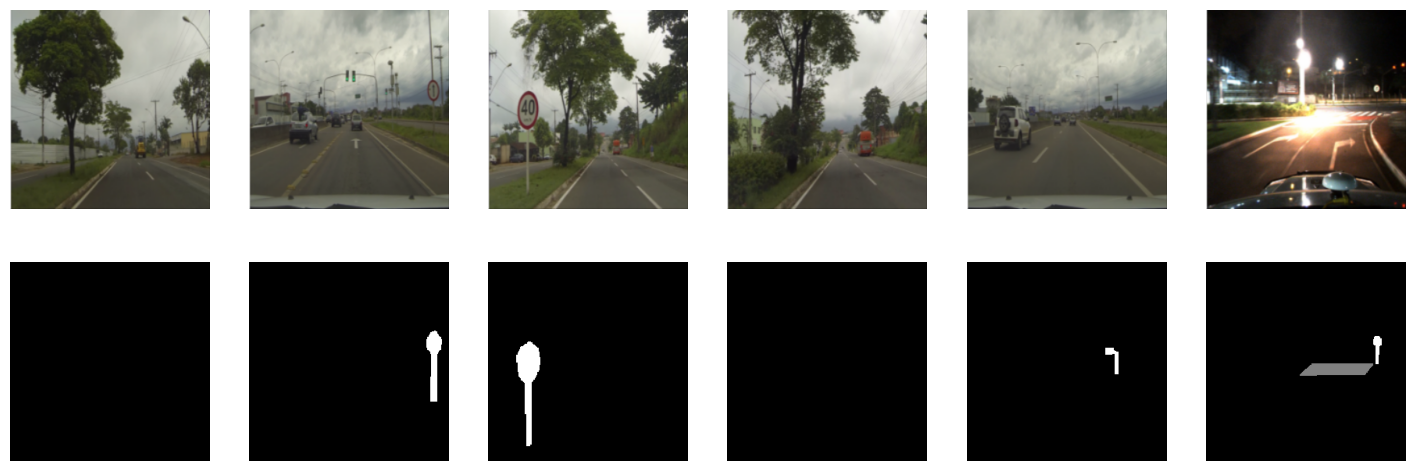

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100+10*i;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

### Preparing target values for the classification task

Let us find all possible Y values in the dataset

In [ ]:
unique, counts = np.unique(Y, return_counts=True)

result = np.column_stack((unique, counts))
print(result)

[[        0 192720674]
 [        1   8499283]
 [        2    827531]]


If number of non-black pixels is less than threshold, then we say that there is not a road sign on the photo

In [ ]:
sum_by_image = np.sum(Y, (1, 2, 3))
print(sum_by_image.shape)

(3083,)


In [ ]:
unique, counts = np.unique(sum_by_image, return_counts=True)
result = np.column_stack((unique, counts))
print (result)

[[    0   461]
 [    8     1]
 [   32     1]
 ...
 [29420     1]
 [29790     1]
 [33807     1]]


In [ ]:
threshold = 40 # TODO: Define threshold for the number of non-black pixels
Y_c = np.array(sum_by_image > threshold, dtype='uint8')
print(Y_c.shape)

(3083,)


Now we have labels for classification task

In [ ]:
print(Y_c[0:100])

[0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0]


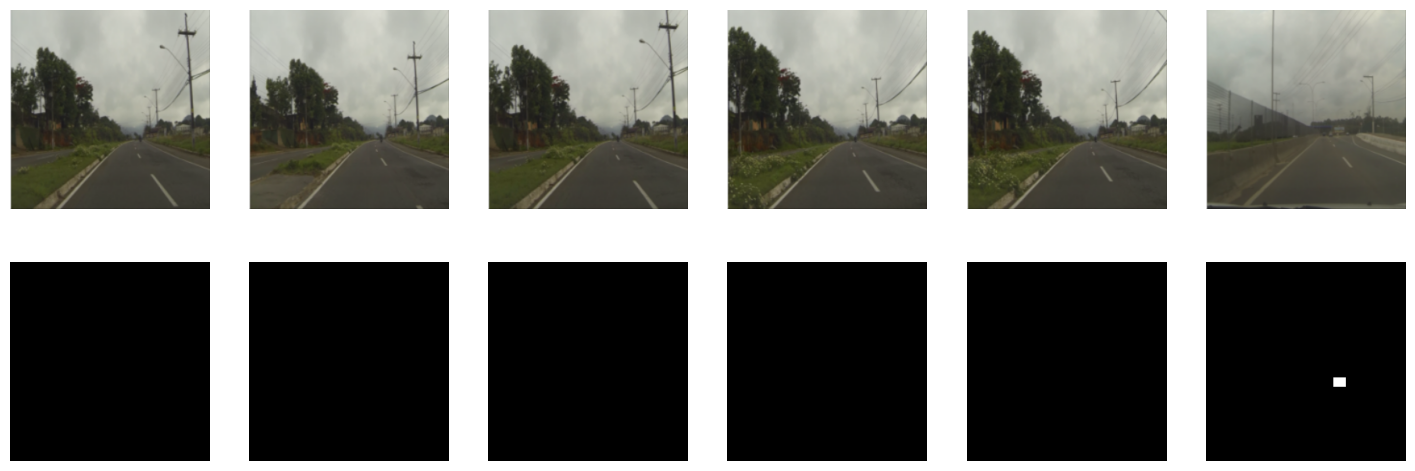

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 2 + i;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

### Data normalization

For pytorch, the channel should be the second dimension, not the last one.

In [ ]:
X_r = np.transpose(X, axes=(0, 3, 1, 2))
Y_r = Y_c
print(X_r.shape, Y_r.shape)

(3083, 3, 256, 256) (3083,)


Normalize data and convert to tensors

In [ ]:
X_f = np.array(X_r / 255, dtype='float32') # convert 0-255 values to 0-1
X_t = torch.FloatTensor(X_f)

for x in X_t:
  transforms.functional.normalize(x, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225), inplace=True)

Y_t = torch.FloatTensor(Y_r)

Splitting dataset

Let us divide for traning, validation and test correspondingly.

In [ ]:
ix = np.random.choice(len(X_t), len(X_t), False)
val_index = 2783 # set the index where dataset will be splitted between train and validation
test_index = 2983 # set the index where dataset will be splitted between validation and test
# it is also possible to use train_test_split
tr, val, ts = np.split(ix, [val_index, test_index])

In [ ]:
X_train_t = X_t[tr]
X_val_t = X_t[val]
X_test_t = X_t[ts]

Y_train_t = Y_t[tr]
Y_val_t = Y_t[val]
Y_test_t = Y_t[ts]

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

In [ ]:
unique, counts = np.unique(Y_train_t, return_counts=True)
result = np.column_stack((unique, counts))
print (result)

[[0.000e+00 4.250e+02]
 [1.000e+00 2.358e+03]]


Check converted and normalized data

In [ ]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
      if hasattr(plt_ax, 'set_title'):
        plt_ax.set_title(title)
      if hasattr(plt_ax, 'title'):
        plt_ax.title(title)
    plt_ax.grid(False)

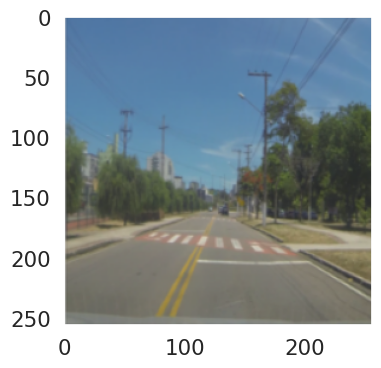

In [ ]:
imshow(X_train_t[0])

### Classes balancing and creating dataloaders

Let's count how many pictures we have for each class.

In [ ]:
unique, counts = np.unique(Y_r, return_counts=True)
result = np.column_stack((unique, counts))
print(result)

[[   0  464]
 [   1 2619]]


The dataset is not balanced, so let's define the weights for each class.

In order for the classes to be balanced in training, we calculate the weights and create a sampler.
For the validation and test, we will not use balancing.

In [ ]:
unique, counts = np.unique(Y_r[tr], return_counts=True)
w = np.min(counts)/counts
print(w)

[1.         0.18023749]


In [ ]:
weights = [w[0] if x == 0 else w[1] for x in Y_r[tr]]
sampler = torch.utils.data.WeightedRandomSampler(weights=weights, num_samples=len(weights))

print(Y_r[tr][50:100:5])
print(weights[50:100:5])

[1 1 1 1 1 1 0 1 0 1]
[0.18023748939779474, 0.18023748939779474, 0.18023748939779474, 0.18023748939779474, 0.18023748939779474, 0.18023748939779474, 1.0, 0.18023748939779474, 1.0, 0.18023748939779474]


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Let's check that the classes are balanced now

In [ ]:
YY_check = np.array([])

for _, y in train_dataloader:
  YY_check = np.hstack((YY_check, y.detach().numpy()))

unique, counts = np.unique(YY_check, return_counts=True)
result = np.column_stack((unique, counts))
print(result)

[[0.000e+00 1.352e+03]
 [1.000e+00 1.431e+03]]


Taking into account the imbalance of classes in the validation and test samples, we will use a special metric to evaluate the quality of training.

In [ ]:
from sklearn.metrics import balanced_accuracy_score

## Custom classifier and training

**Pass requirement**: balanced_accuracy_score metric on the test part of the dataset is at least **0.95**.

In [ ]:
class SimpleCnn(nn.Module):

    def __init__(self, size, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(8)
        ) # => 128x8
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(16)
        ) # => 64x16
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(32)
        ) # => 32x32
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(64)
        ) # => 16x64

        fc_inputs = int((size/16)*(size/16)*64)

        self.out = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fc_inputs, 96 * 6),
            nn.ReLU(),
            nn.BatchNorm1d(96 * 6),
            nn.Dropout(p=0.2),
            nn.Linear(96 * 6, 96 * 6),
            nn.ReLU(),
            nn.BatchNorm1d(96 * 6),
            nn.Dropout(p=0.2),
            nn.Linear(96 * 6, n_classes)
        )


    def forward(self, x):
        x = self.conv4(self.conv3(self.conv2(self.conv1(x))))
        x = x.view(x.size(0), -1)
        logits = self.out(x)

        return logits.squeeze()

Let us define training function

In [ ]:
X_f = 0

In [ ]:
from tqdm import tqdm_notebook

In [ ]:
def train(model, optimizer, loss_function, train_dataloader, val_dataloader, max_epochs = 10, scheduler=None):
  losses_train = np.zeros(max_epochs)
  losses_val = np.zeros(max_epochs)

  for epoch in range(max_epochs):

    # Train loop
    model.train()
    for it, (X_batch, y_batch) in tqdm(enumerate(train_dataloader),
                                      total=len(train_dataloader),
                                      desc=f"Training on epoch {epoch+1}"):
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()

      outp = model(X_batch) # predict y with model using X_batch

      loss = loss_function(outp.squeeze(), y_batch)
      losses_train[epoch] = losses_train[epoch] + loss.detach().flatten()[0]

      loss.backward()   # call back propagation and gradient calculation
      optimizer.step()  # call weights update

      if scheduler is not None:
        scheduler.step()

      y_batch = y_batch.cpu()
      X_batch = X_batch.cpu()
      outp = outp.cpu()

    print(f"Epoch {epoch+1}: train loss={losses_train[epoch]}")

    # Validation loop
    model.eval()
    with torch.no_grad():
      for i, batch in tqdm(enumerate(val_dataloader),
                      total=len(val_dataloader),
                      desc=f"Testing on epoch {epoch+1}"):
        imgs, labels = batch
        # Compute prediction and loss
        pred = model(imgs.to(device))
        loss = loss_function(pred.squeeze(), labels.to(device))
        losses_val[epoch] = losses_val[epoch] + loss.detach().flatten()[0]


        imgs = imgs.cpu()
        labels = labels.cpu()
        pred = pred.cpu()

      print(f"Validation loss: {losses_val[epoch]}\n")

  return losses_train, losses_val

Now we can create model, define loss function and optimizer

In [ ]:
simpleNN = SimpleCnn(256, 1).to(device)
loss_function = nn.BCEWithLogitsLoss()
learning_rate = 1e-4
optimizer = torch.optim.Adam(simpleNN.parameters(), lr=learning_rate)

and train our model

In [ ]:
max_epochs =  20
losses = train(simpleNN, optimizer, loss_function, train_dataloader, val_dataloader, max_epochs)

In [ ]:
def plot_losses(losses):
  plt.figure(figsize=(12, 8))
  plt.plot(range(len(losses[0])), losses[0], label='train loss')
  plt.plot(range(len(losses[1])), losses[1], label='val loss')
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

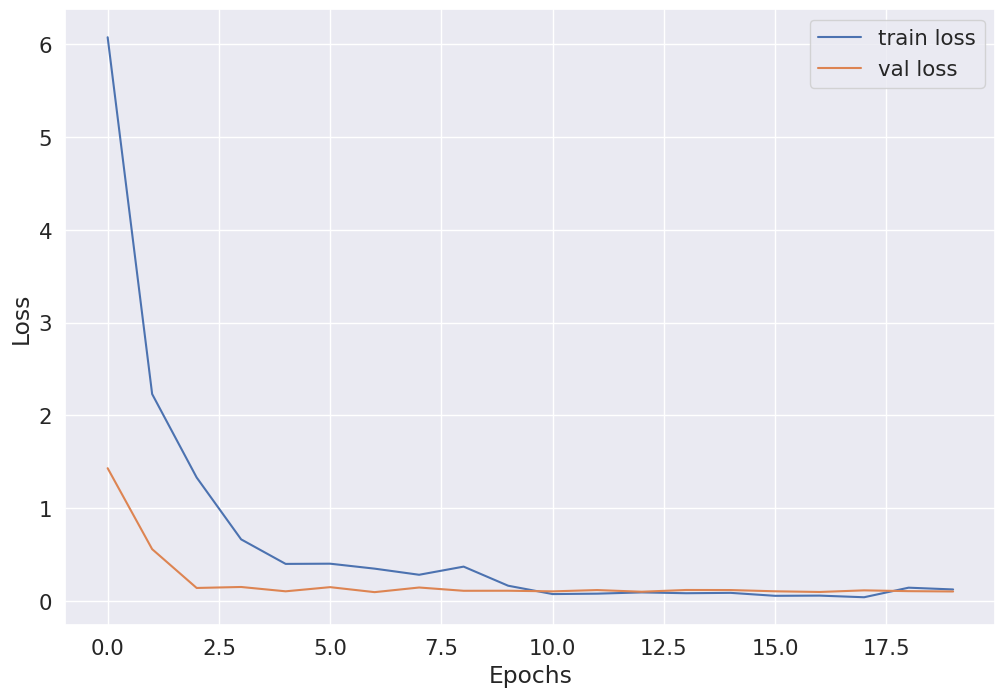

In [ ]:
plot_losses(losses)

## Model validation

In order to check overfitting we compate metric results on the train and validation datasets. If everything is ok, then we check on test dataset.

In [ ]:
@torch.no_grad()
def predict(dataloader, model):
    model.eval()
    predictions = np.array([])
    y_target = np.array([])
    for x_batch, y_batch in dataloader:
        y_target = np.hstack((y_target, y_batch.numpy().flatten()))
        x_batch = x_batch.to(device)
        lgts = model(x_batch)
        probs = torch.sigmoid(lgts)
        preds = (probs > 0.5).type(torch.long).cpu()
        predictions = np.hstack((predictions, preds.numpy().flatten()))
        x_batch = x_batch.cpu()
    model.train()
    # We return also target for the cases, when data is shuffled
    return predictions.flatten(), y_target

In [ ]:
Y_pred_train, Y_target_train = predict(train_dataloader, simpleNN)
balanced_accuracy_score(Y_target_train, Y_pred_train)

0.9982282069454288

In [ ]:
Y_pred_val, Y_target_val = predict(val_dataloader, simpleNN)
balanced_accuracy_score(Y_target_val, Y_pred_val)

0.9754360108081552

In [ ]:
Y_test_pred, Y_test_target = predict(test_dataloader, simpleNN)
balanced_accuracy_score(Y_test_target, Y_test_pred)

0.9315476190476191

## Data Augmentation

In the common case the best way to increase size of the dataset is using on-fly data augmentation. In this case each time when we get item from the dataset transformation with random parameters is applied. However, the transformations must give you realistic images that are similar to the original images.

For the on-fly transformations we will create custom class dataset

In [ ]:
class OurOwnDataset(Dataset):
    def __init__(self, data, labels, transforms=None):
        self.data = data
        self.labels = labels
        self.transforms = transforms

        print(f'Found {len(self.data)} items')

    def __getitem__(self, i):
        image = self.data[i]

        if self.transforms:
            image = self.transforms(image)

        label = self.labels[i]

        return image, label

    def __len__(self):
        return len(self.df)

In [ ]:
from torchvision.transforms.v2 import Compose, RandomHorizontalFlip, RandomPerspective, GaussianBlur

getitem_transforms = Compose([
  RandomHorizontalFlip(p=0.5),
  RandomPerspective(distortion_scale=0.3),
  GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 3.))
])

train_dataset_augmented = OurOwnDataset(X_train_t, Y_train_t, transforms=getitem_transforms)

Found 2783 items


Check how it is working

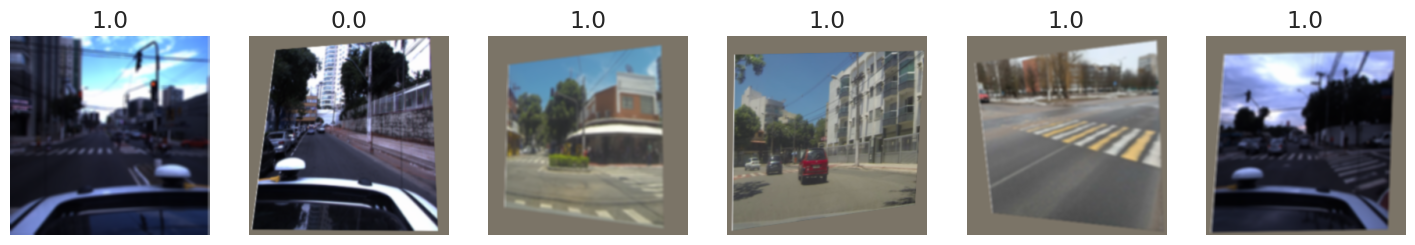

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100+10*i;
    image, label = train_dataset_augmented.__getitem__(j)

    plt.subplot(2, 6, i+1)
    plt.axis("off")

    imshow(image, title=f'{label}', plt_ax=plt)
plt.show();

In [ ]:
train_dataloader_augmented = DataLoader(train_dataset_augmented, batch_size=128, sampler=sampler)

Now we can create new model and train it

In [ ]:
model2 = SimpleCnn(256, 1).to(device)

learning_rate2 = 1e-4
optimizer2 = torch.optim.Adam(model2.parameters(), lr=learning_rate2)

In [ ]:
losses2 = train(model2, optimizer2, loss_function, train_dataloader_augmented, val_dataloader, 10)

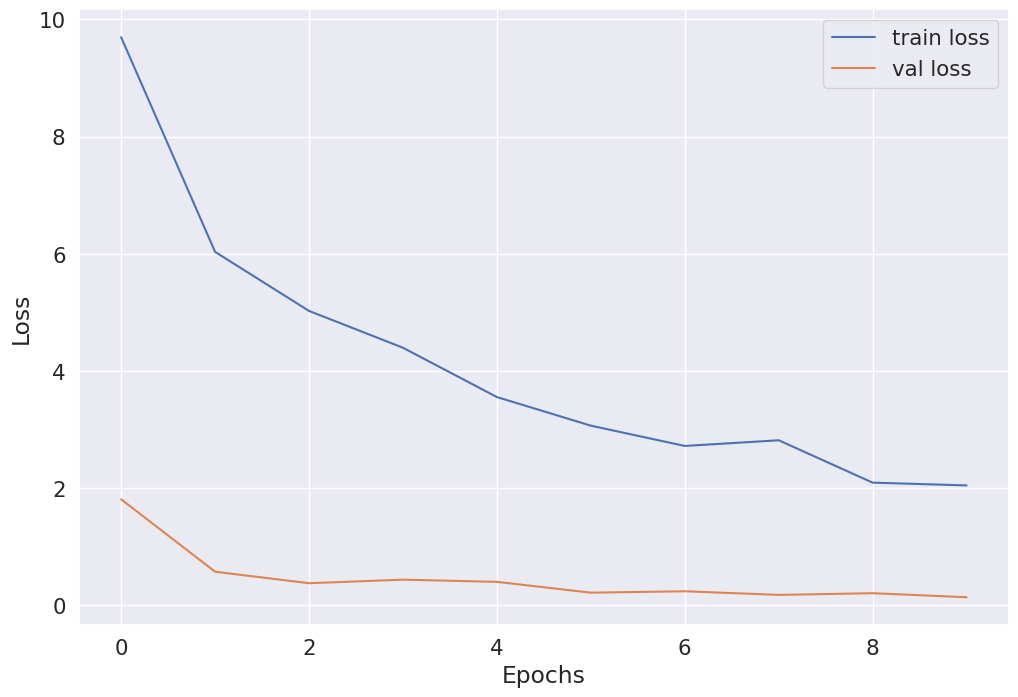

In [ ]:
plot_losses(losses2)

Check accuracy

In [ ]:
Y_train_pred2, Y_train_target2 = predict(train_dataloader_augmented, model2)

**Pass requirement**: balanced_accuracy_score metric on the test part of the dataset is at least 0.96.

In [ ]:
Y_pred_test2, Y_target_test2 = predict(test_dataloader, model2)
balanced_accuracy_score(Y_target_test2, Y_pred_test2)

0.9669614345369688

## Transfer learning

The main idea is to load model and slightly tune it's parameters. The pre-trained models can be found in various libraries, for example in pytorch, or more specifically in [torchvision.models](https://pytorch.org/vision/stable/models.html#classification)

In [ ]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

model3 = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
print(model3)

First of all we must change the number of the outputs. For example, the models trained on IMAGENET have 1000 outputs, but we need only 1 output.

We can replace the whole classifier block (which is placed after convolution layers) or the last layer of the classifier.

In [ ]:
from itertools import chain

# Disable gradient calculations for the pretrained model
# It will speed up the calculations and it is a way for freeze parameters values
for param in model3.parameters():
  param.requires_grad = False

layers_to_unfreeze = 2

# Unfreeze some of the last layers
for param in model3.features[-layers_to_unfreeze:].parameters():
    param.requires_grad = True

num_features = model3.classifier[1].in_features

model3.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features=num_features, out_features=1024),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(p=0.4),
    nn.Linear(in_features=1024, out_features=512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.4),
    nn.Linear(in_features=512, out_features=1)
)

In [ ]:
model3 = model3.to(device)

In [ ]:
from torch.optim import lr_scheduler

# tune only classifier parameters by passing only that params to the optimizer
optimizer3 = torch.optim.Adam(
    chain(
        list(model3.features[-layers_to_unfreeze:].parameters()),
        model3.classifier.parameters()
    ),
    lr=1e-4,
)

loss_function = nn.BCEWithLogitsLoss()
losses3 = train(model3, optimizer3, loss_function, train_dataloader, val_dataloader, 20)

And a bit more epochs

In [ ]:
losses3_1 = train(model3, optimizer3, loss_function, train_dataloader, val_dataloader, 7)

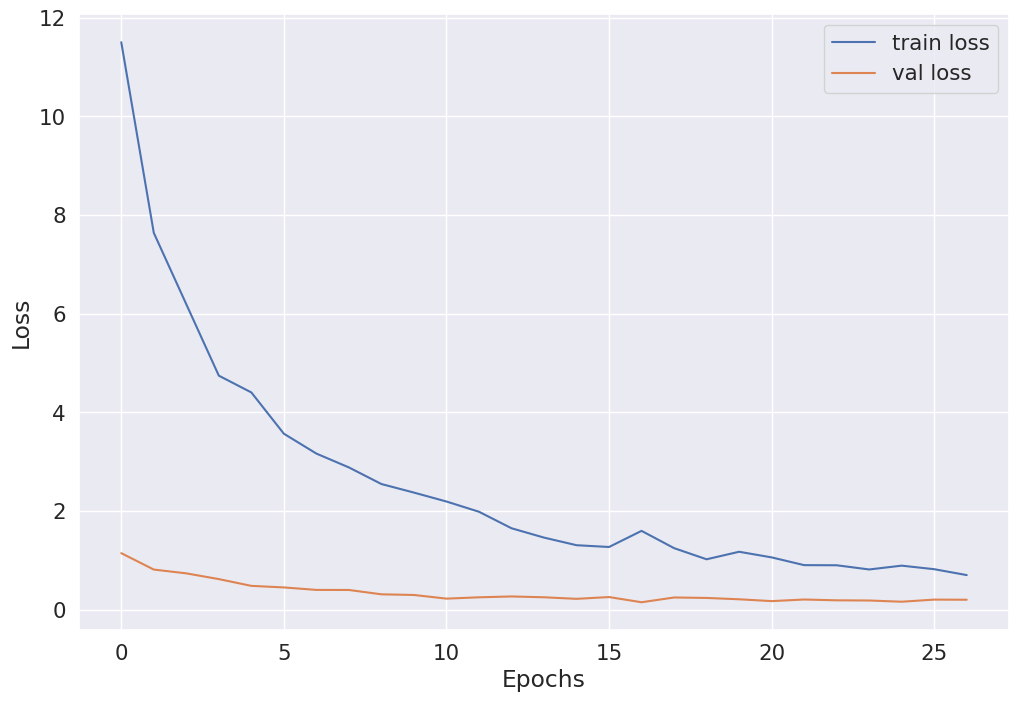

In [ ]:
plot_losses(np.hstack((np.array(losses3), np.array(losses3_1))))

In [ ]:
Y_pred_train3, Y_train_target3 = predict(train_dataloader, model3)
balanced_accuracy_score(Y_train_target3, Y_pred_train3)

0.9981508875739644

In [ ]:
Y_pred_test3, Y_target_test3 = predict(test_dataloader, model3)
balanced_accuracy_score(Y_target_test3, Y_pred_test3)

0.9641365757799067